# LOX Family Expression Analysis in Annotated GSE240016

This notebook analyzes mouse LOX-family genes (`Lox`, `Loxl1`, `Loxl2`, `Loxl3`, `Loxl4`) in the annotated CD45-negative aging thymic stromal dataset. Age is defined by `stage`: `02mo` young and `18mo` old.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy import sparse
from scipy.stats import mannwhitneyu, spearmanr

np.random.seed(0)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white")
sns.set_theme(style="whitegrid", context="paper")

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
BASIC_FIG_DIR = FIGURES_DIR / "LOX_basic"
EMT_FIG_DIR = FIGURES_DIR / "LOX_EMT_correlation"
for path in [PROCESSED_DIR, FIGURES_DIR, BASIC_FIG_DIR, EMT_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

LOX_GENES = ["Lox", "Loxl1", "Loxl2", "Loxl3", "Loxl4"]
AGE_KEY = "stage"
YOUNG_LABEL = "02mo"
OLD_LABEL = "18mo"
AGE_PALETTE = {YOUNG_LABEL: "#0072B2", OLD_LABEL: "#D55E00"}

## 2. Load Annotated Data

The object comes from notebook 04 and retains the published `cell_type`, `cell_type_subset`, and UMAP coordinates.

In [2]:
input_path = PROCESSED_DIR / "thymus_annotated.h5ad"
if not input_path.exists():
    raise FileNotFoundError(f"Missing {input_path}. Run notebook 04 first.")

adata = sc.read_h5ad(input_path)
if AGE_KEY not in adata.obs.columns:
    raise KeyError("Expected adata.obs['stage'] with 02mo and 18mo labels.")

missing_lox = [gene for gene in LOX_GENES if gene not in adata.var_names]
if missing_lox:
    raise KeyError(f"Missing mouse LOX genes in adata.var_names: {missing_lox}")

adata.obs["age_group"] = adata.obs[AGE_KEY].astype("category")
print(adata)
print(adata.obs[AGE_KEY].value_counts())
print(adata.obs["cell_type"].value_counts())
print(adata.obs["cell_type_subset"].value_counts().head(20))

AnnData object with n_obs × n_vars = 22877 × 25211
    obs: 'sample', 'stage', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.4', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'leiden_0.1', 'leiden_0.3', 'leiden_0.5', 'leiden_0.7', 'leiden_0.9', 'cell_type', 'cell_type_subset', 'age_group'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'day_colors', 'hvg', 'leiden'

## 3. Helper Functions

In [3]:
def expression_vector(adata_like, gene):
    values = adata_like[:, gene].X
    if sparse.issparse(values):
        values = values.toarray()
    return np.asarray(values).ravel()


def expression_dataframe(adata_like, genes, columns):
    frame = adata_like.obs[columns].copy()
    for gene in genes:
        frame[gene] = expression_vector(adata_like, gene)
    return frame


def rank_biserial_from_u(u_stat, n_old, n_young):
    return (2 * u_stat / (n_old * n_young)) - 1


def mask_for_analysis_cell_type(adata_obj, label):
    broad = adata_obj.obs["cell_type"].astype(str)
    subset = adata_obj.obs["cell_type_subset"].astype(str)
    if label == "cTEC":
        return subset.str.contains("cTEC", case=False, regex=False)
    if label == "mTEC":
        return subset.str.contains("mTEC", case=False, regex=False)
    if label == "fibroblasts":
        return broad.eq("FB")
    if label == "endothelial":
        return broad.eq("EC")
    raise ValueError(label)

analysis_cell_types = ["cTEC", "mTEC", "fibroblasts", "endothelial"]

## Analysis 1 - Basic Expression Overview

We plot LOX-family expression by age across all cells and by the published broad cell-type annotation.

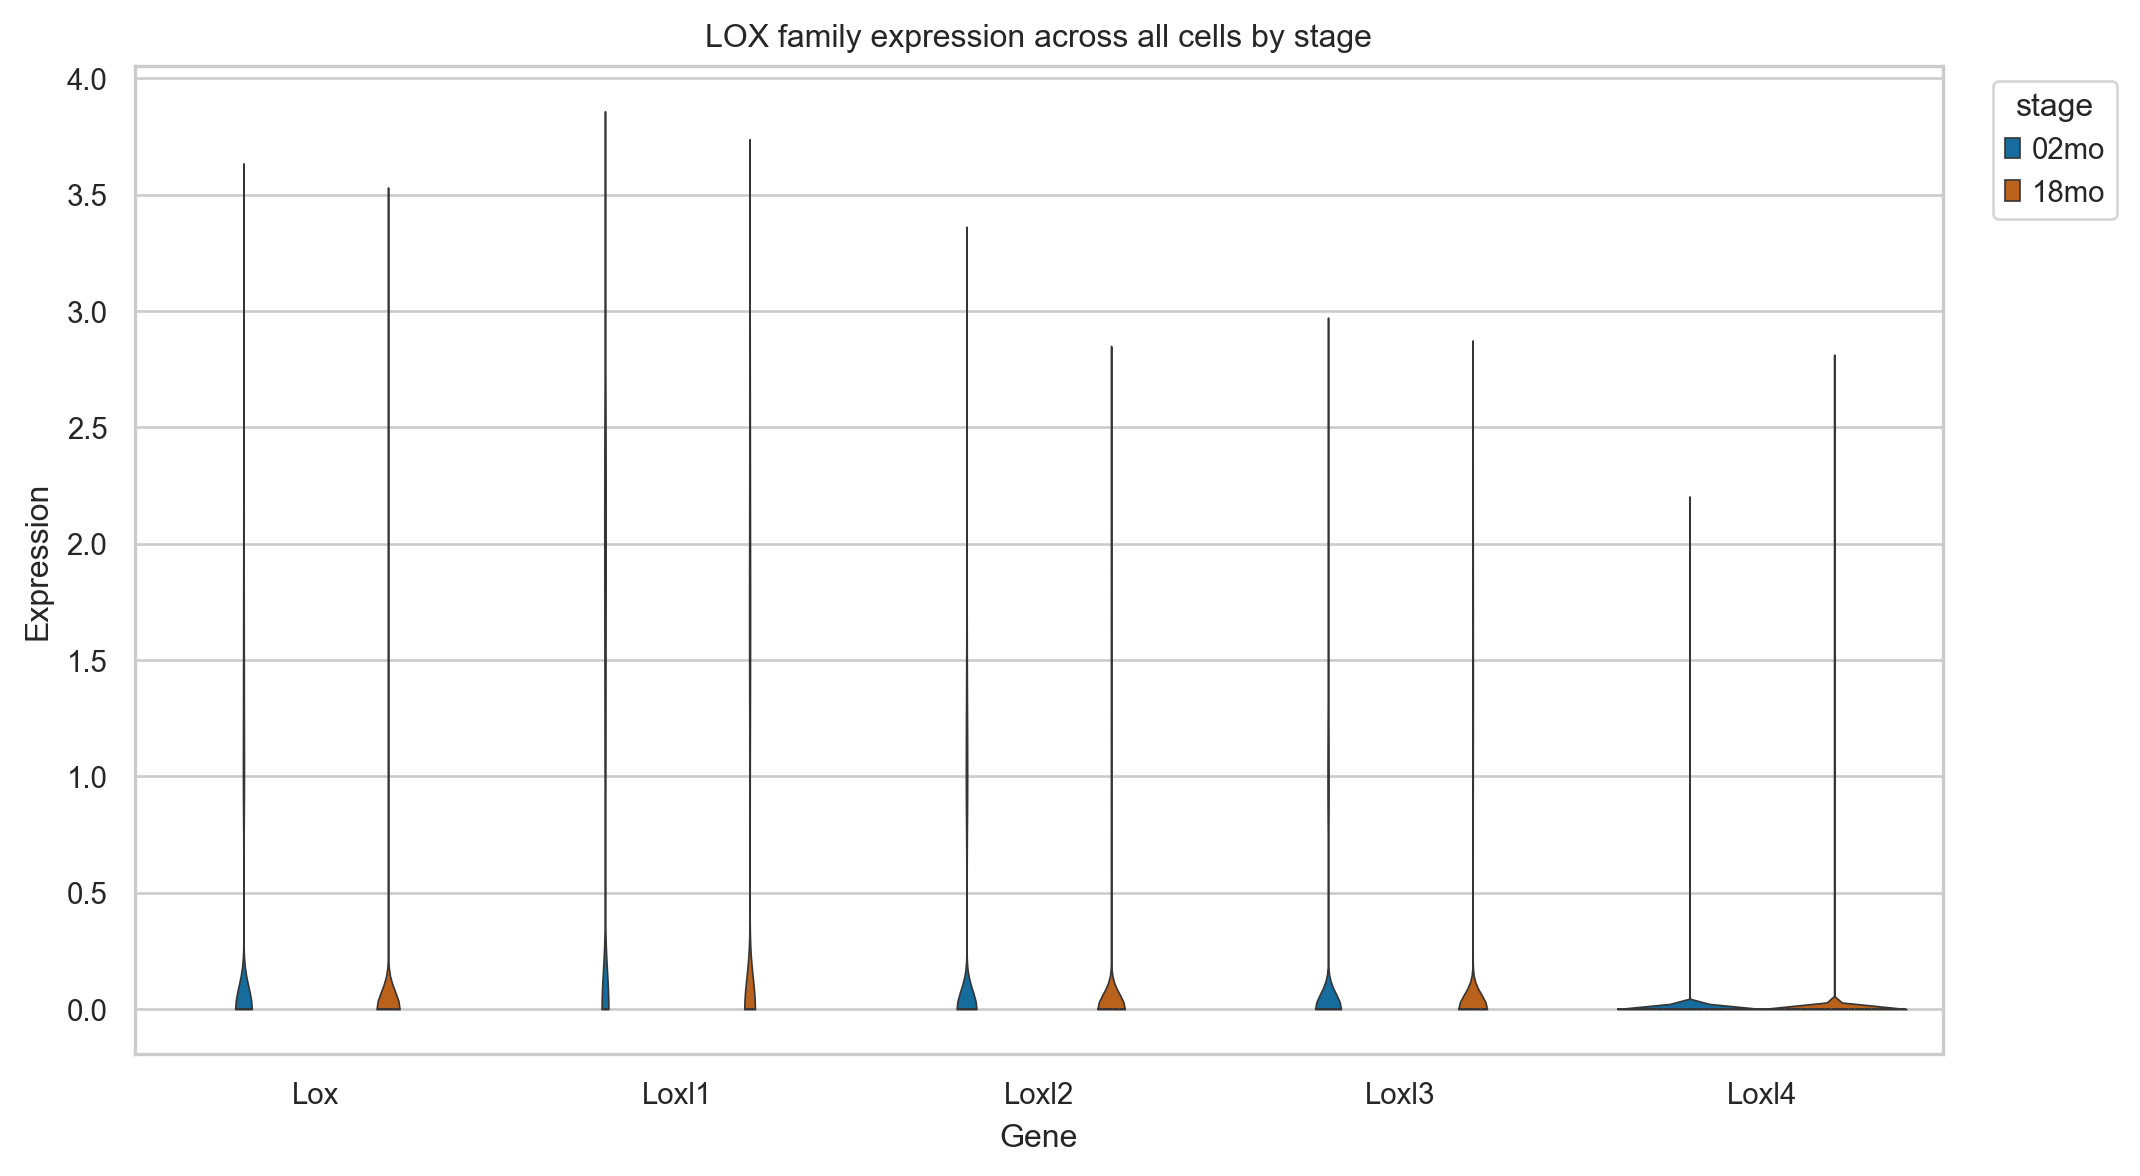

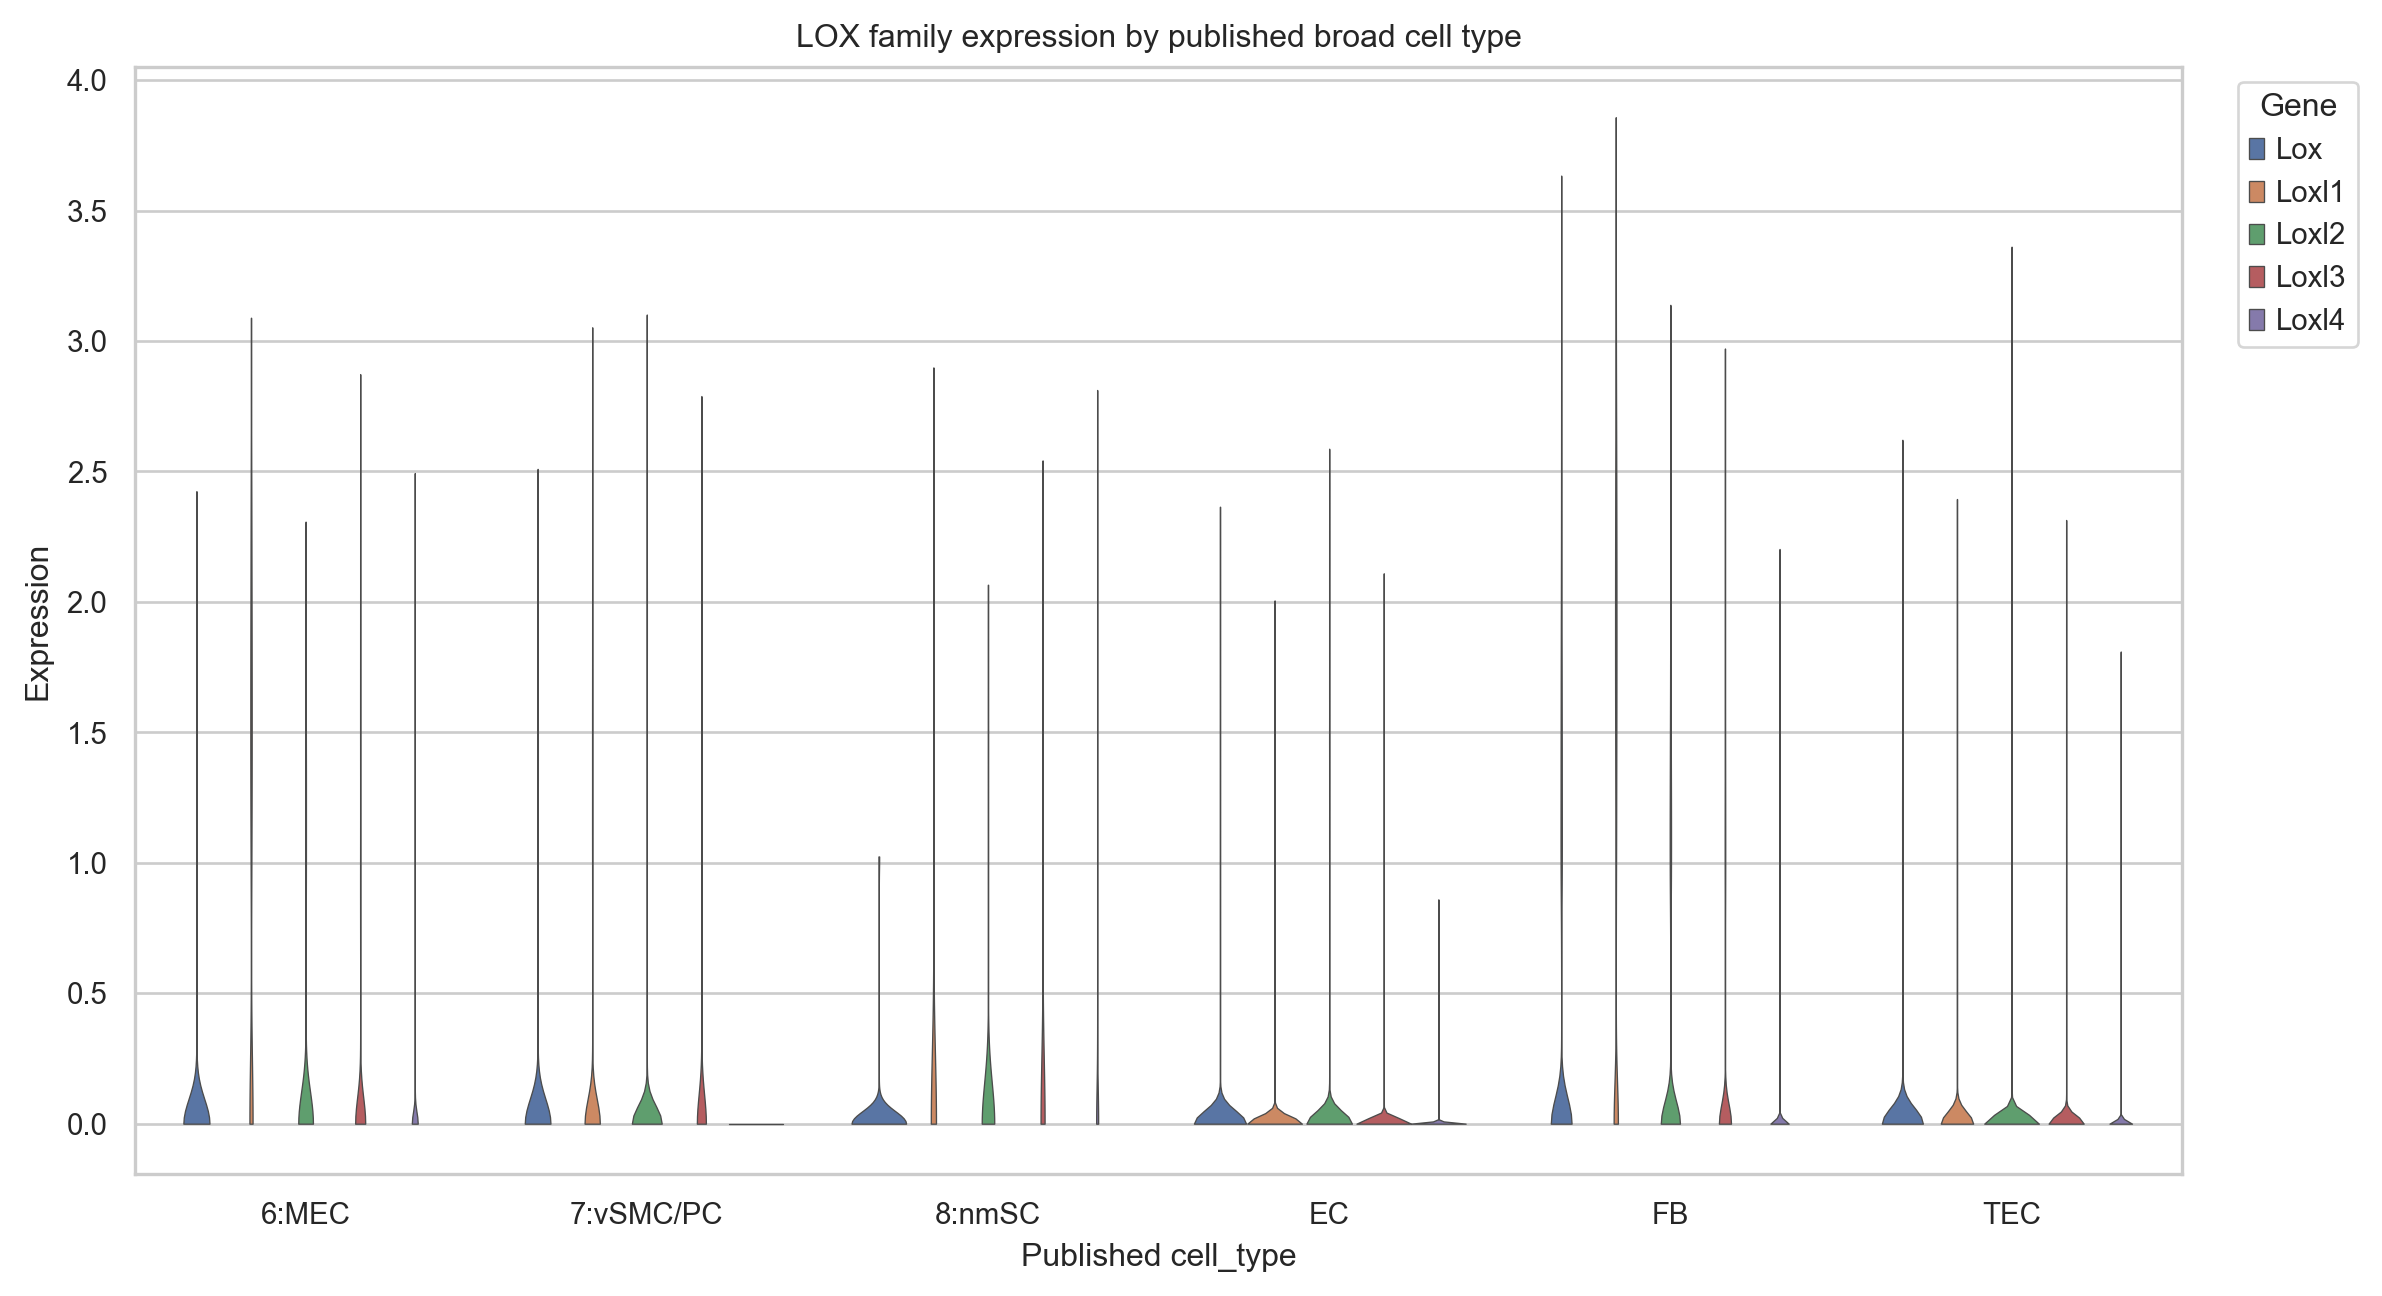

In [4]:
overview_df = expression_dataframe(adata, LOX_GENES, [AGE_KEY, "cell_type", "cell_type_subset"])
overview_long = overview_df.melt(id_vars=[AGE_KEY, "cell_type", "cell_type_subset"], value_vars=LOX_GENES, var_name="gene", value_name="expression")

plt.figure(figsize=(9, 5))
sns.violinplot(data=overview_long, x="gene", y="expression", hue=AGE_KEY, palette=AGE_PALETTE, cut=0, inner="quartile", linewidth=0.5)
plt.title("LOX family expression across all cells by stage")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.legend(title=AGE_KEY, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(BASIC_FIG_DIR / "LOX_violin_all_cells_by_stage.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5.5))
sns.violinplot(data=overview_long, x="cell_type", y="expression", hue="gene", cut=0, inner=None, linewidth=0.4)
plt.title("LOX family expression by published broad cell type")
plt.xlabel("Published cell_type")
plt.ylabel("Expression")
plt.legend(title="Gene", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(BASIC_FIG_DIR / "LOX_violin_by_cell_type.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis 2 - Cell-Type-Specific Aging

We test old (`18mo`) versus young (`02mo`) expression separately in cTECs, mTECs, fibroblasts, and endothelial cells. cTECs/mTECs are defined from `cell_type_subset`; fibroblasts/endothelial cells are defined from broad `cell_type`.

cTEC: 374 cells


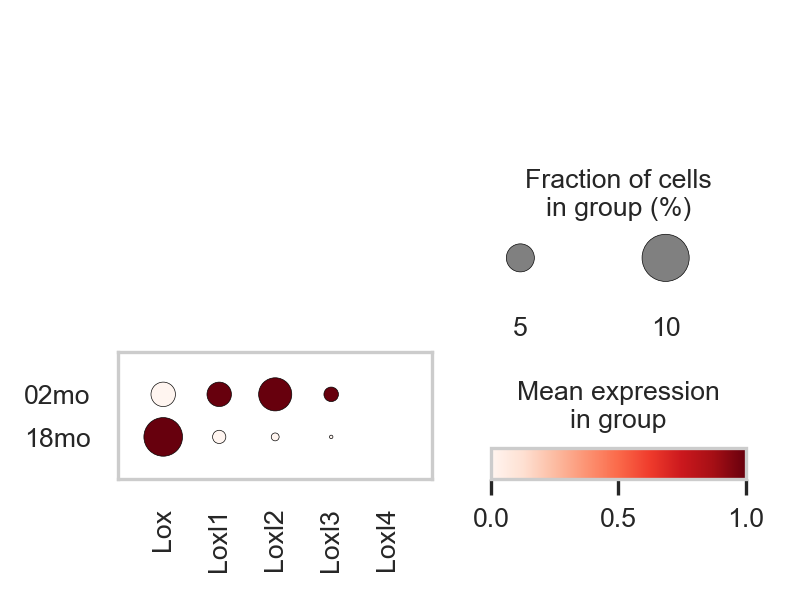

mTEC: 3401 cells


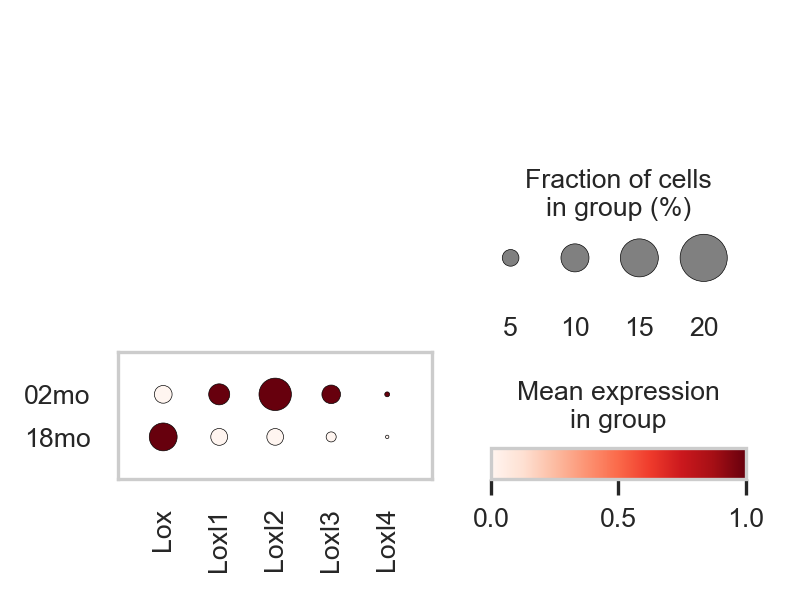

fibroblasts: 13238 cells


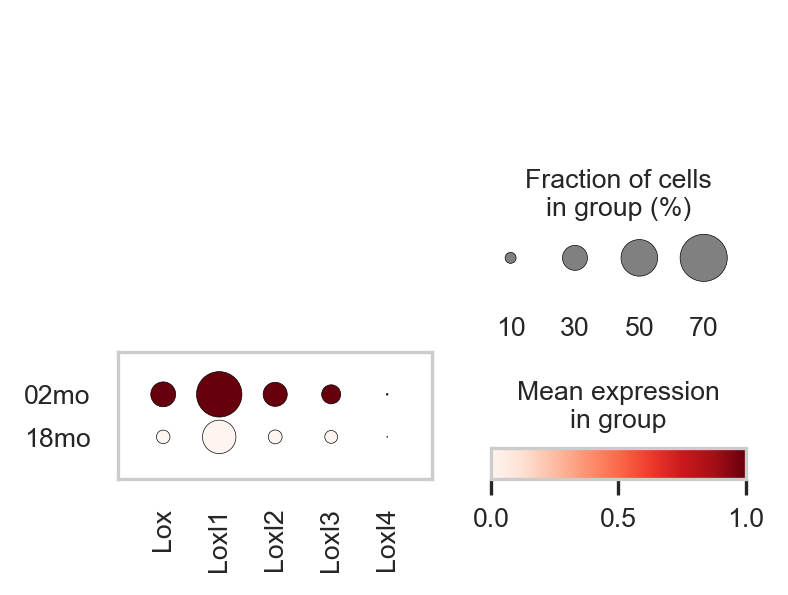

endothelial: 1660 cells


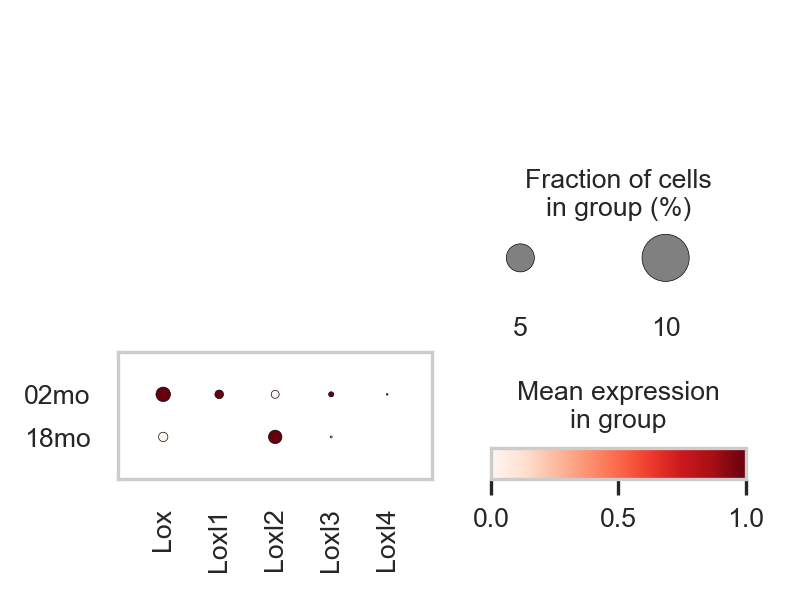

Saved differential results to: D:\ThymusLOXScan\data\processed\LOX_differential_results.csv


,cell_type_analysis,gene,young_label,old_label,n_young_cells,n_old_cells,mean_young,mean_old,median_young,median_old,mannwhitney_u,p_value,rank_biserial_effect_size_old_vs_young
11,fibroblasts,Loxl1,02mo,18mo,7159,6079,1.280954,0.853648,1.480994,0.0,16846071.5,2.624136e-121,-0.225816
10,fibroblasts,Lox,02mo,18mo,7159,6079,0.424104,0.219481,0.000000,0.0,18407397.5,4.891322e-98,-0.154063
12,fibroblasts,Loxl2,02mo,18mo,7159,6079,0.345092,0.207739,0.000000,0.0,18917674.0,3.192340e-72,-0.130613
13,fibroblasts,Loxl3,02mo,18mo,7159,6079,0.238477,0.186198,0.000000,0.0,20229790.0,1.416607e-26,-0.070313
7,mTEC,Loxl2,02mo,18mo,1747,1654,0.098052,0.038586,0.000000,0.0,1341851.5,1.757470e-13,-0.071235
5,mTEC,Lox,02mo,18mo,1747,1654,0.053215,0.127383,0.000000,0.0,1513001.5,2.175738e-07,0.047227
8,mTEC,Loxl3,02mo,18mo,1747,1654,0.051185,0.025978,0.000000,0.0,1398327.5,3.065587e-06,-0.032145
14,fibroblasts,Loxl4,02mo,18mo,7159,6079,0.008625,0.005085,0.000000,0.0,21662073.0,7.687666e-04,-0.004490
2,cTEC,Loxl2,02mo,18mo,48,326,0.041459,0.007436,0.000000,0.0,7408.5,6.391303e-03,-0.053106
16,endothelial,Loxl1,02mo,18mo,966,694,0.015994,0.000000,0.000000,0.0,331732.0,7.204418e-03,-0.010352


In [5]:
stats_rows = []
for label in analysis_cell_types:
    mask = mask_for_analysis_cell_type(adata, label)
    n_cells = int(mask.sum())
    print(f"{label}: {n_cells} cells")
    if n_cells == 0:
        continue
    subset = adata[mask].copy()

    sc.pl.dotplot(subset, LOX_GENES, groupby=AGE_KEY, standard_scale="var", show=False)
    plt.savefig(BASIC_FIG_DIR / f"LOX_dotplot_{label}_by_stage.png", dpi=300, bbox_inches="tight")
    plt.show()

    age_values = subset.obs[AGE_KEY].astype(str).to_numpy()
    young_mask = age_values == YOUNG_LABEL
    old_mask = age_values == OLD_LABEL
    for gene in LOX_GENES:
        expr = expression_vector(subset, gene)
        young_expr = expr[young_mask]
        old_expr = expr[old_mask]
        if len(young_expr) and len(old_expr):
            test = mannwhitneyu(old_expr, young_expr, alternative="two-sided")
            u_stat = float(test.statistic)
            p_value = float(test.pvalue)
            effect = float(rank_biserial_from_u(u_stat, len(old_expr), len(young_expr)))
        else:
            u_stat = np.nan; p_value = np.nan; effect = np.nan
        stats_rows.append({
            "cell_type_analysis": label,
            "gene": gene,
            "young_label": YOUNG_LABEL,
            "old_label": OLD_LABEL,
            "n_young_cells": int(len(young_expr)),
            "n_old_cells": int(len(old_expr)),
            "mean_young": float(np.mean(young_expr)) if len(young_expr) else np.nan,
            "mean_old": float(np.mean(old_expr)) if len(old_expr) else np.nan,
            "median_young": float(np.median(young_expr)) if len(young_expr) else np.nan,
            "median_old": float(np.median(old_expr)) if len(old_expr) else np.nan,
            "mannwhitney_u": u_stat,
            "p_value": p_value,
            "rank_biserial_effect_size_old_vs_young": effect,
        })

differential_results = pd.DataFrame(stats_rows).sort_values("p_value", na_position="last")
output_csv = PROCESSED_DIR / "LOX_differential_results.csv"
differential_results.to_csv(output_csv, index=False)
print(f"Saved differential results to: {output_csv}")
differential_results.head(20)

## Analysis 3 - LOXL2 Co-expression with EMT Markers in Fibroblasts

In fibroblasts (`cell_type == FB`), we test whether `Loxl2` correlates with `Vim`, `Col1a1`, and `Snai1`.

C:\Users\sasha\AppData\Roaming\Python\Python311\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


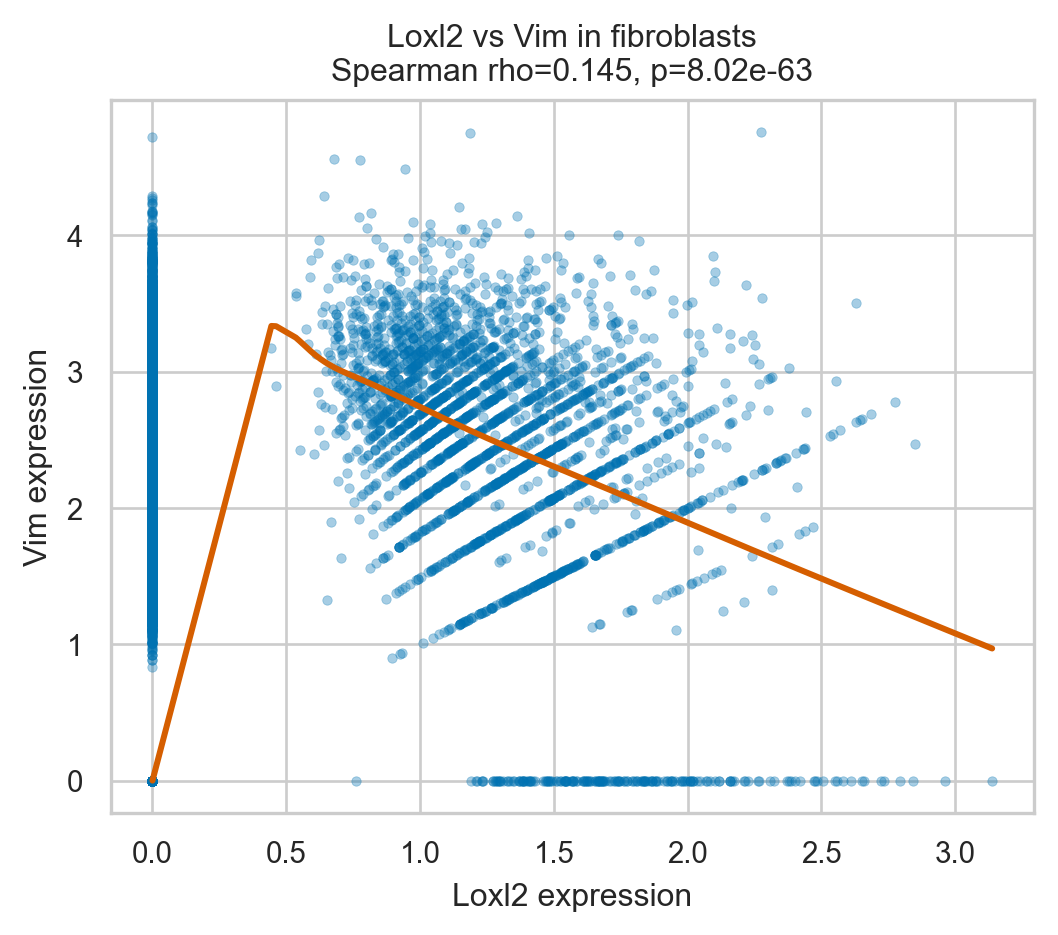

C:\Users\sasha\AppData\Roaming\Python\Python311\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


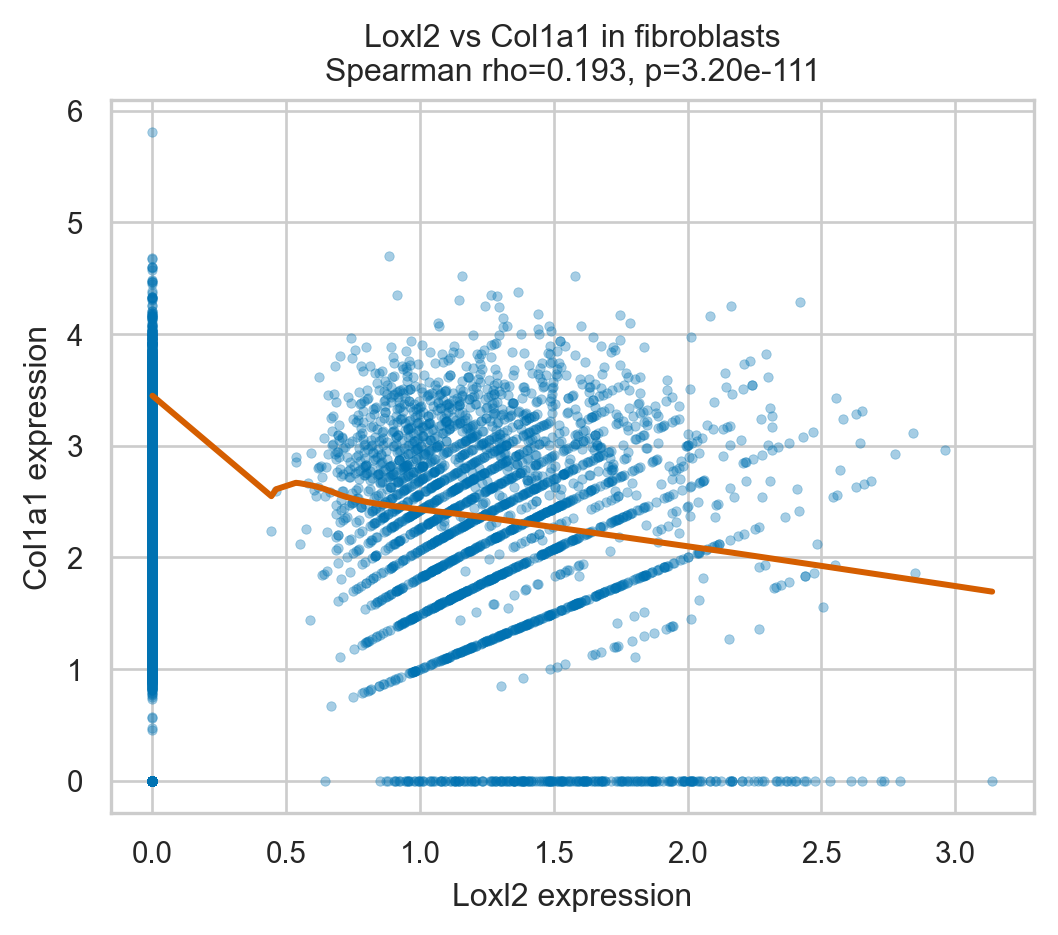

C:\Users\sasha\AppData\Roaming\Python\Python311\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


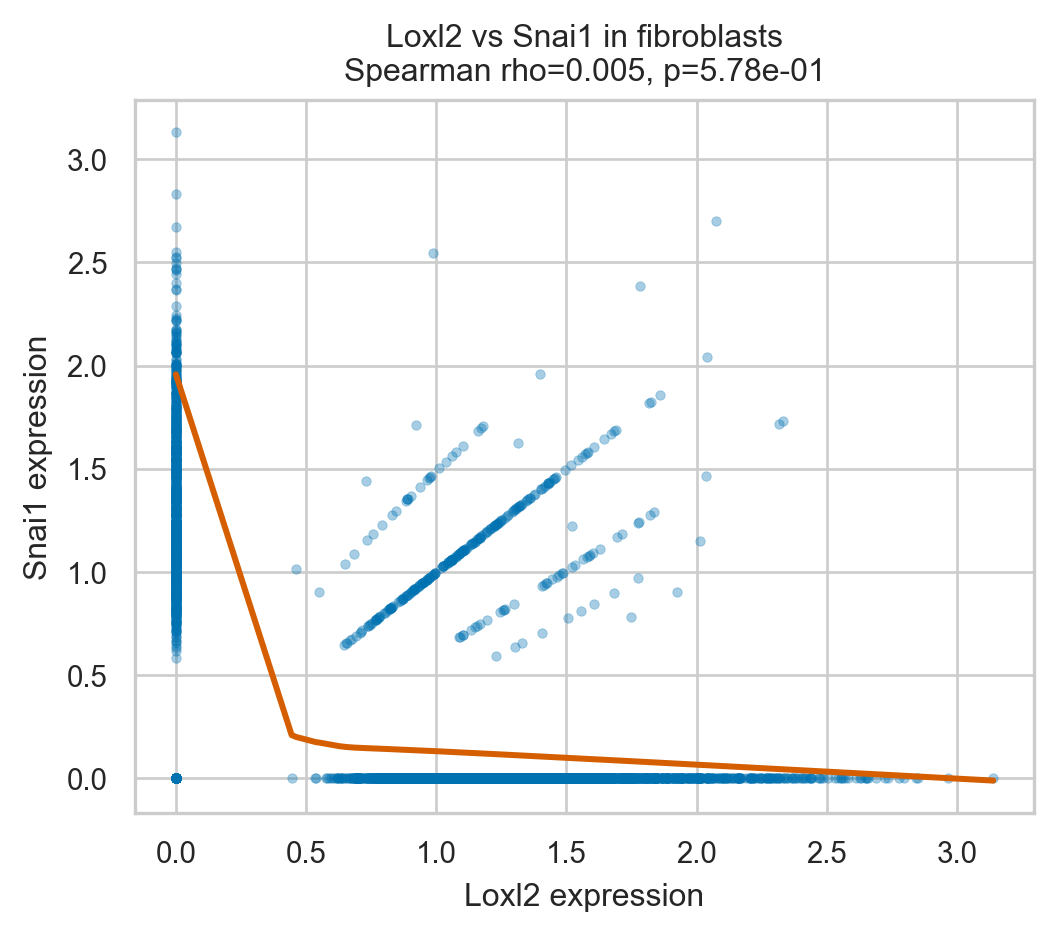

,gene_x,gene_y,spearman_rho,p_value,n_cells
0,Loxl2,Vim,0.144649,8.019905e-63,13238
1,Loxl2,Col1a1,0.192952,3.203431e-111,13238
2,Loxl2,Snai1,0.004830,5.784416e-01,13238


In [6]:
emt_genes = ["Vim", "Col1a1", "Snai1"]
missing_emt = [gene for gene in ["Loxl2"] + emt_genes if gene not in adata.var_names]
if missing_emt:
    raise KeyError(f"Missing EMT correlation genes: {missing_emt}")

fibro = adata[adata.obs["cell_type"].astype(str).eq("FB")].copy()
if fibro.n_obs == 0:
    raise ValueError("No fibroblasts found as cell_type == 'FB'.")

correlation_rows = []
x = expression_vector(fibro, "Loxl2")
for marker in emt_genes:
    y = expression_vector(fibro, marker)
    rho, p_value = spearmanr(x, y)
    correlation_rows.append({"gene_x": "Loxl2", "gene_y": marker, "spearman_rho": rho, "p_value": p_value, "n_cells": fibro.n_obs})
    plt.figure(figsize=(4.5, 4))
    sns.scatterplot(x=x, y=y, s=8, alpha=0.35, color="#0072B2", edgecolor=None)
    sns.regplot(x=x, y=y, scatter=False, lowess=True, color="#D55E00")
    plt.title(f"Loxl2 vs {marker} in fibroblasts\nSpearman rho={rho:.3f}, p={p_value:.2e}")
    plt.xlabel("Loxl2 expression")
    plt.ylabel(f"{marker} expression")
    plt.tight_layout()
    plt.savefig(EMT_FIG_DIR / f"Loxl2_vs_{marker}_fibroblasts.png", dpi=300, bbox_inches="tight")
    plt.show()

emt_correlations = pd.DataFrame(correlation_rows)
emt_correlations.to_csv(PROCESSED_DIR / "LOXL2_EMT_spearman_correlations.csv", index=False)
emt_correlations

## Analysis 4 - Summary Figure

A four-panel 300 DPI summary figure highlights global expression, the strongest cell-type aging result, fibroblast LOXL2/EMT co-expression, and mean LOX expression by broad cell type.

C:\Users\sasha\AppData\Local\Temp\ipykernel_16276\2310288060.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=best_df, x=AGE_KEY, y=best["gene"], palette=AGE_PALETTE, width=0.55, fliersize=1, ax=axes[0,1])


C:\Users\sasha\AppData\Roaming\Python\Python311\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


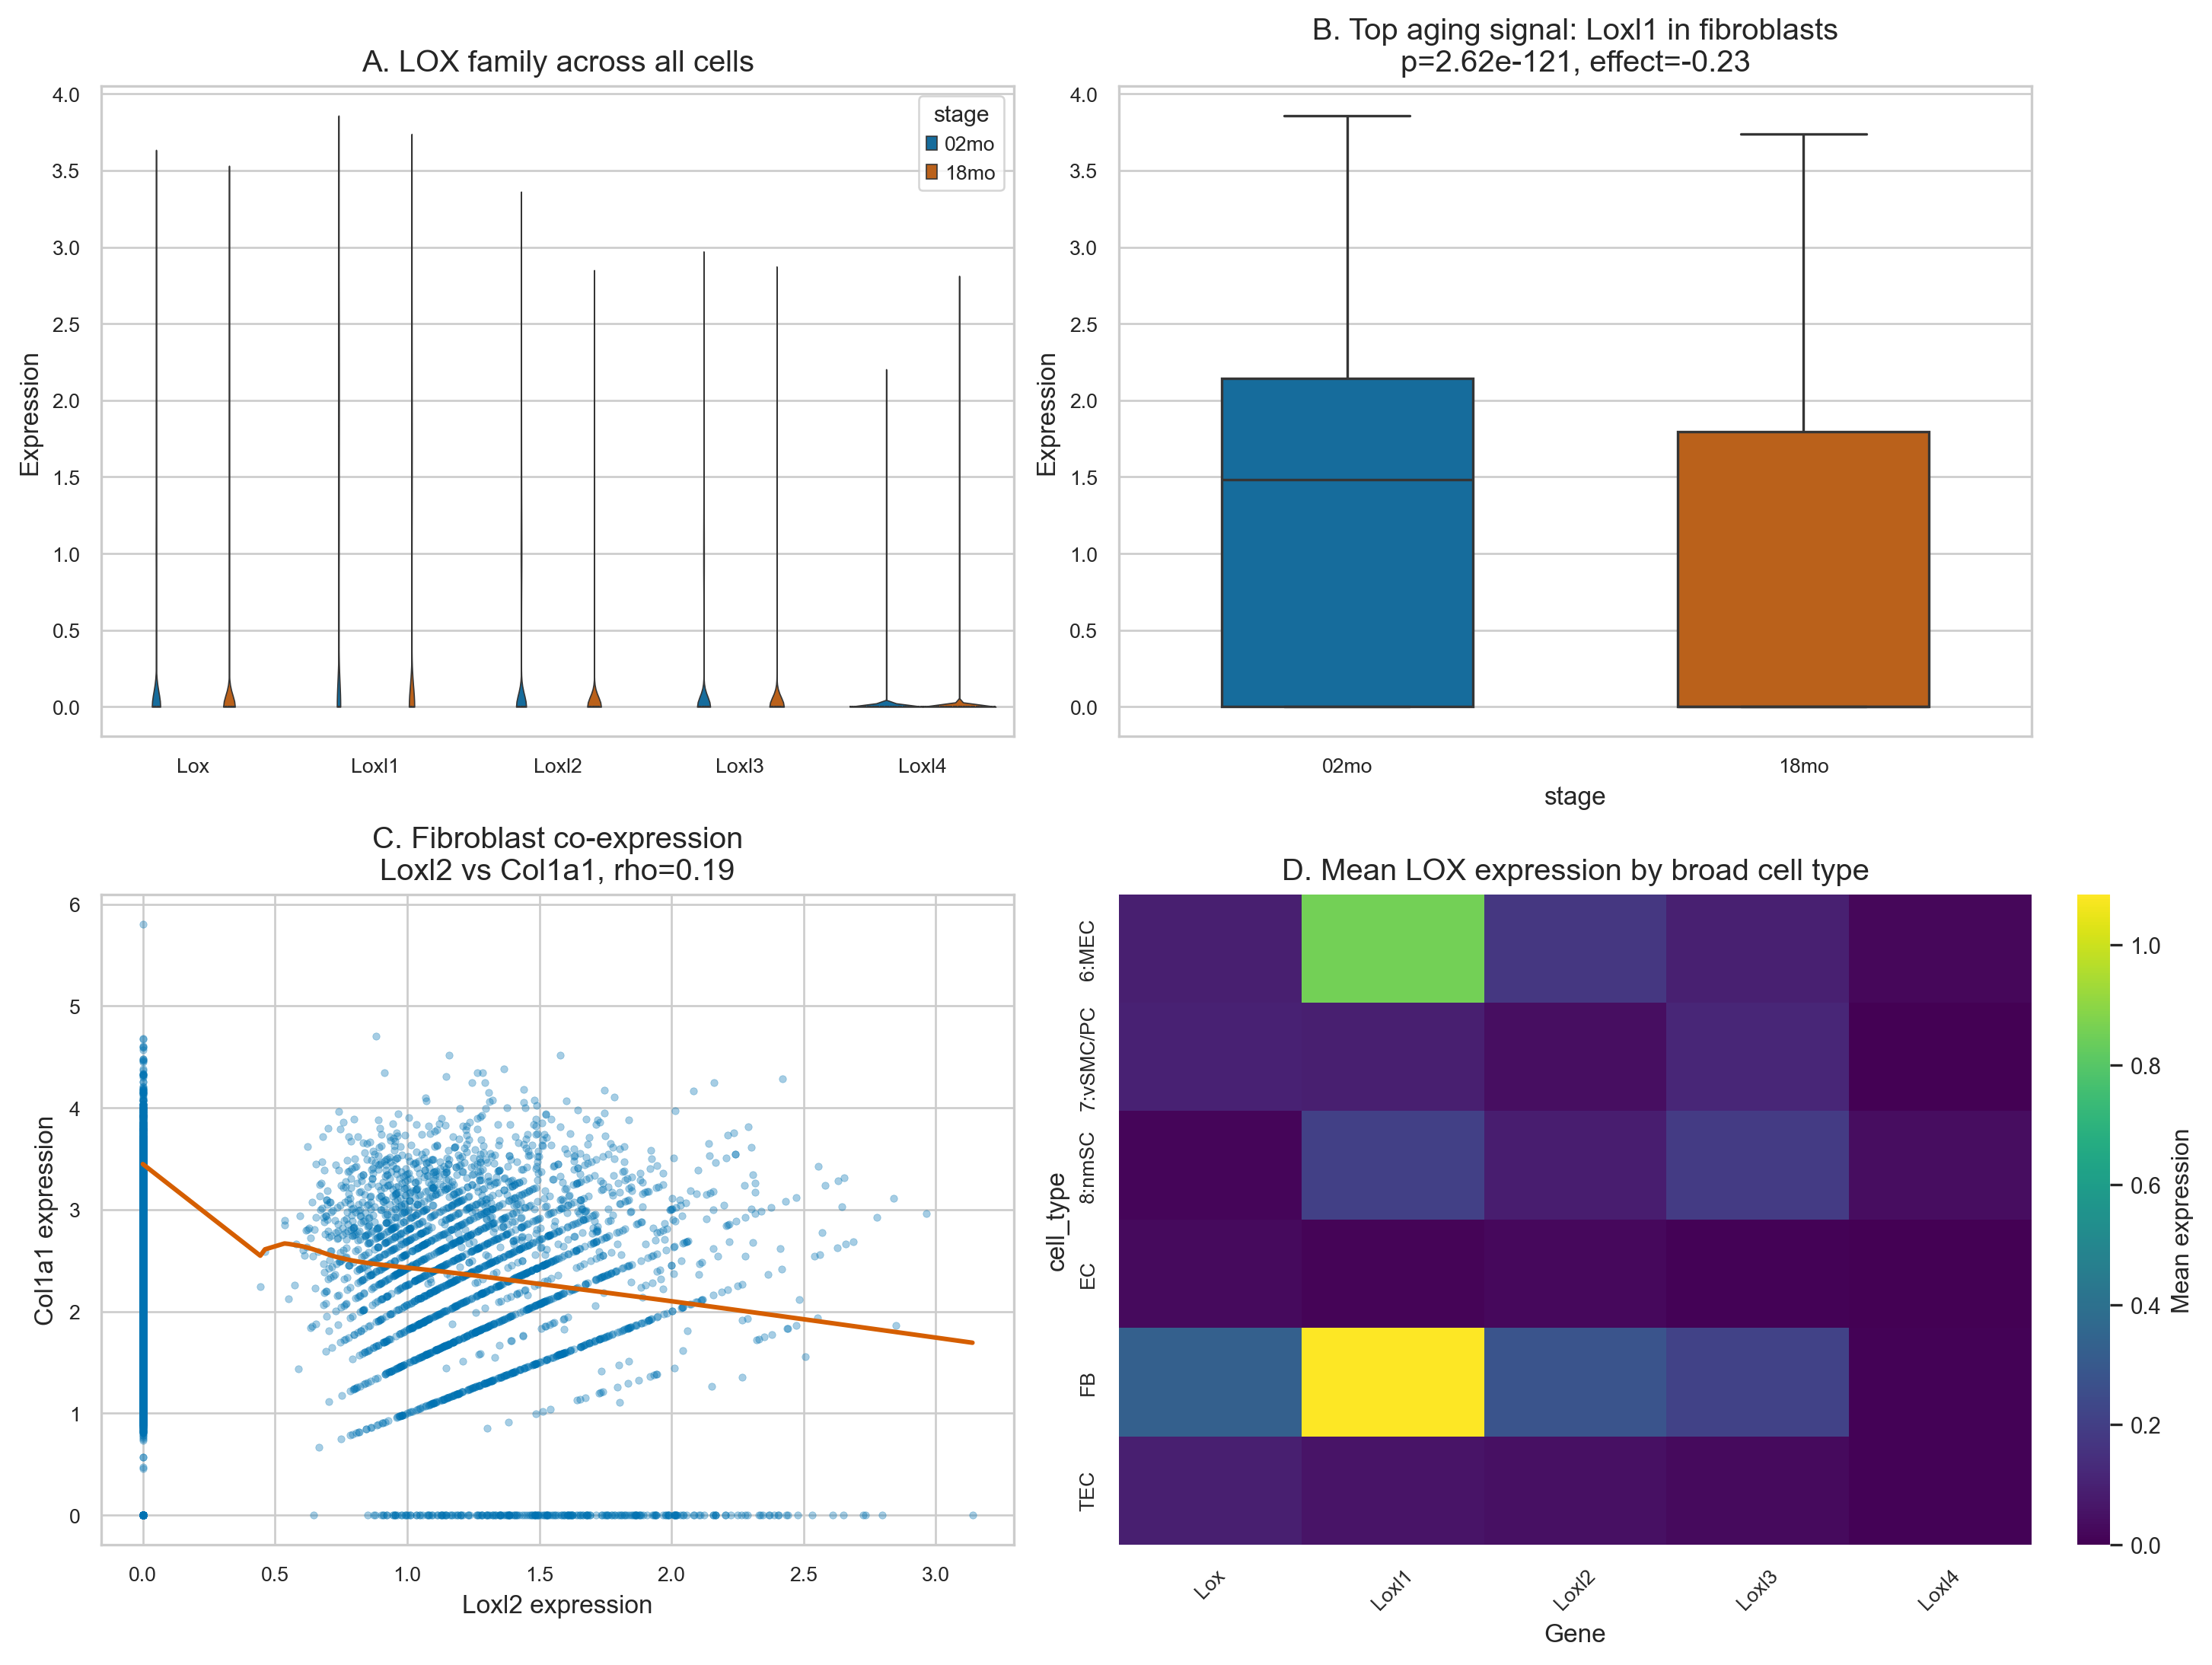

Saved summary figure to: D:\ThymusLOXScan\figures\LOX_summary_figure.png


In [7]:
summary_path = FIGURES_DIR / "LOX_summary_figure.png"
best_result = differential_results.dropna(subset=["p_value"]).head(1)
mean_expr = overview_long.groupby(["cell_type", "gene"], observed=False)["expression"].mean().reset_index()
heatmap_df = mean_expr.pivot(index="cell_type", columns="gene", values="expression").fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

sns.violinplot(data=overview_long, x="gene", y="expression", hue=AGE_KEY, palette=AGE_PALETTE, cut=0, inner="quartile", linewidth=0.5, ax=axes[0,0])
axes[0,0].set_title("A. LOX family across all cells", fontsize=12)
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Expression", fontsize=10)
axes[0,0].legend(title=AGE_KEY, fontsize=8, title_fontsize=9)

if not best_result.empty:
    best = best_result.iloc[0]
    mask = mask_for_analysis_cell_type(adata, best["cell_type_analysis"])
    best_df = expression_dataframe(adata[mask].copy(), [best["gene"]], [AGE_KEY])
    sns.boxplot(data=best_df, x=AGE_KEY, y=best["gene"], palette=AGE_PALETTE, width=0.55, fliersize=1, ax=axes[0,1])
    axes[0,1].set_title(f"B. Top aging signal: {best['gene']} in {best['cell_type_analysis']}\np={best['p_value']:.2e}, effect={best['rank_biserial_effect_size_old_vs_young']:.2f}", fontsize=12)
    axes[0,1].set_xlabel(AGE_KEY, fontsize=10)
    axes[0,1].set_ylabel("Expression", fontsize=10)
else:
    axes[0,1].text(0.5, 0.5, "No valid aging test results", ha="center", va="center")
    axes[0,1].set_axis_off()

best_corr = emt_correlations.reindex(emt_correlations["spearman_rho"].abs().sort_values(ascending=False).index).iloc[0]
y = expression_vector(fibro, best_corr["gene_y"])
sns.scatterplot(x=x, y=y, s=8, alpha=0.35, color="#0072B2", edgecolor=None, ax=axes[1,0])
sns.regplot(x=x, y=y, scatter=False, lowess=True, color="#D55E00", ax=axes[1,0])
axes[1,0].set_title(f"C. Fibroblast co-expression\nLoxl2 vs {best_corr['gene_y']}, rho={best_corr['spearman_rho']:.2f}", fontsize=12)
axes[1,0].set_xlabel("Loxl2 expression", fontsize=10)
axes[1,0].set_ylabel(f"{best_corr['gene_y']} expression", fontsize=10)

sns.heatmap(heatmap_df, cmap="viridis", ax=axes[1,1], cbar_kws={"label": "Mean expression"})
axes[1,1].set_title("D. Mean LOX expression by broad cell type", fontsize=12)
axes[1,1].set_xlabel("Gene", fontsize=10)
axes[1,1].set_ylabel("cell_type", fontsize=10)
axes[1,1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1,1].tick_params(axis="y", labelsize=8)

for ax in axes.flat:
    ax.tick_params(labelsize=8)

plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved summary figure to: {summary_path}")

## Preliminary interpretation

After execution, use `LOX_differential_results.csv`, `LOXL2_EMT_spearman_correlations.csv`, and the summary figure to decide which hypothesis is supported. Broad upregulation in `18mo` supports **LOX up**; broad downregulation supports **LOX down**; mixed directions by gene or compartment support **differential by isoform**. Because this dataset separates TEC subsets and stromal compartments, prioritize whether the signal is strongest in cTEC, mTEC, fibroblast, or endothelial analyses rather than interpreting all CD45-negative cells as one pool.